#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import gaussian_kde

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = f"{indir}/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
RNA_origin="our"

# get the RNA by sublass df
with open("../../../input/01-youth/subclass_order_for_integration_with_zeng.txt", "rt") as f:
    subclass_list=f.read().split("\n")[:-1]
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv(f"{indir}/02-{RNA_origin}_subclass_mean_dat_final.csv",index_col=0).T.loc[subclass_list,:]

max_threshold_=0.2
cv_threshold_=0.5
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]

/tmp/ipykernel_33021/1738856184.py:15: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


In [3]:
df_RNA_selected

,ENSMUSG00000002459.17,ENSMUSG00000025905.13,ENSMUSG00000033740.17,ENSMUSG00000067879.3,ENSMUSG00000025915.14,ENSMUSG00000042501.12,ENSMUSG00000048960.13,ENSMUSG00000057715.13,ENSMUSG00000016918.15,ENSMUSG00000025938.16,...,ENSMUSG00000041380.13,ENSMUSG00000041552.7,ENSMUSG00000055109.5,ENSMUSG00000057457.11,ENSMUSG00000031295.13,ENSMUSG00000043518.7,ENSMUSG00000059493.13,ENSMUSG00000018589.8,ENSMUSG00000031342.17,ENSMUSG00000031355.16
L2/3 IT CTX Glut,0.448792,0.005035,0.046114,0.207789,0.362265,0.079146,0.097084,0.897737,0.127858,0.049769,...,0.253324,0.221620,0.662567,0.033990,0.441692,0.173914,0.108630,0.031375,1.557669,0.274268
L4/5 IT CTX Glut,0.216942,0.005031,0.048328,0.202655,0.220502,0.041154,0.070895,0.920933,0.025175,0.046214,...,0.094245,0.240255,0.618612,0.016697,0.318969,0.123799,0.114187,0.020968,1.359220,0.037610
L5 IT CTX Glut,0.298333,0.073934,0.059012,0.447046,0.256952,0.081433,0.100054,1.290858,0.314146,0.033014,...,0.077972,0.281579,0.690358,0.040255,0.395165,0.115802,0.047558,0.047414,1.662062,0.068164
L2/3 IT RSP Glut,0.120910,0.007577,0.055370,0.106949,0.116874,0.095534,0.078498,0.674450,0.020874,0.055777,...,0.610916,0.111297,0.143765,0.014781,0.356306,0.132250,0.117629,0.012894,1.143473,0.191057
L4 RSP-ACA Glut,0.205377,0.000696,0.064740,0.228852,0.180255,0.030968,0.116164,0.901231,0.031824,0.024859,...,0.444679,0.139608,0.191093,0.014479,0.319706,0.147804,0.068797,0.027591,1.159937,0.248915
L5 ET CTX Glut,0.362239,0.005511,0.048472,0.382196,0.337289,0.062434,0.195760,1.488832,0.034364,0.054727,...,0.167447,0.244399,0.781701,0.012874,0.296697,0.048179,0.038362,0.054040,1.466966,0.058011
SUB-ProS Glut,0.139181,0.027242,0.387773,0.375572,0.211054,0.063198,0.360958,1.656061,0.104468,0.048866,...,0.572935,0.062967,0.113314,0.020370,0.375799,0.052768,0.049954,0.076135,1.548696,0.221926
CA1-ProS Glut,0.029245,0.000868,0.082779,0.400339,0.119575,0.030886,0.121185,0.381476,0.013948,0.055868,...,0.088789,0.004425,0.033620,0.016540,0.321699,0.071000,0.023400,0.051210,1.473634,0.027803
CA3 Glut,0.018804,0.000797,0.048171,0.156866,0.042025,0.038949,0.403200,0.999441,0.025677,0.101891,...,0.108389,0.011099,0.026027,0.026354,0.380524,0.013842,0.024440,0.016295,2.322551,0.052636
CLA-EPd-CTX Car3 Glut,0.784285,1.048168,0.053708,0.268693,0.127952,0.019727,0.080715,0.640224,0.461010,0.066713,...,0.656173,0.167309,0.394451,0.021325,0.287587,0.201923,0.956916,0.101207,1.607529,0.149066


In [ ]:
modification="5hmCG"
state="hyper"

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad(f"{indir}/frac_segment_by_subclass_cross/5hmC_merged_allc_with_{modification[:-1]}_segment.h5ad").to_df().iloc[:len(subclass_list),:]
# df_frac_segment_subclass["total5mCG"]=ad.read_h5ad(f"/share/home/renlh/ll/DMR/04_get_h5ad_from_MCDS/frac_segment_by_subclass_cross/5mC_merged_allc_with_{modification[:-1]}_segment.h5ad").to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index
# df_frac_segment_subclass["total5mCG"].index=df_RNA.index
# df_frac_segment_subclass["true5mCG"]=df_frac_segment_subclass["total5mCG"]-df_frac_segment_subclass["5hmCG"]
# df_frac_segment_subclass["true5mCG"].clip(lower=0, inplace=True)

DMR_states_df=ad.read_h5ad(f"{indir}/{modification}_DMR_states_neuron_1vsOthers.h5ad").to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index


In [5]:
differential_segments

Index(['chr1_3019020_3019545', 'chr1_3023074_3023890', 'chr1_3032861_3034192',
       'chr1_3044312_3044993', 'chr1_3074366_3074990', 'chr1_3076706_3077471',
       'chr1_3084207_3084772', 'chr1_3090853_3092180', 'chr1_3096288_3097965',
       'chr1_3098659_3098992',
       ...
       'chr19_61238016_61238441', 'chr19_61267872_61268178',
       'chr19_61268856_61269200', 'chr19_61286843_61287489',
       'chr19_61288301_61288928', 'chr19_61299973_61300405',
       'chr19_61313965_61314559', 'chr19_61317667_61318070',
       'chr19_61319797_61320171', 'chr19_61329595_61329910'],
      dtype='object', name='segment', length=184573)

In [ ]:
loops_df=pd.read_csv(f"{indir}/intergenic_to_selectedGenes_dots_withPCC_3C_RNA.tsv", sep="\t")

In [7]:
loops_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue,subclass,bin1_intergenic,bin1_selected,bin2_intergenic,bin2_selected,bin_status,PCC_3C_RNA
0,chr1,3050000,3060000,chr1,5040000,5050000,305,504,0,0,0.482867,1.000000e-10,1.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(305, 504, 'chr1', 305, 'ENSMUSG00000002459.1..."
1,chr1,3110000,3120000,chr1,6740000,6750000,311,674,0,0,0.363741,6.510000e-08,6.850000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 674, 'chr1', 311, 'ENSMUSG00000033740.1..."
2,chr1,3110000,3120000,chr1,6790000,6800000,311,679,0,0,0.417278,3.000000e-10,4.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 679, 'chr1', 311, 'ENSMUSG00000033740.1..."
3,chr1,3690000,3700000,chr1,6520000,6530000,369,652,0,0,0.316687,2.920000e-08,3.150000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(369, 652, 'chr1', 369, 'ENSMUSG00000033740.1..."
4,chr1,3730000,3740000,chr1,6680000,6690000,373,668,0,0,0.483908,0.000000e+00,0.000000e+00,L2/3 IT CTX Glut,True,False,False,True,1001,"[(373, 668, 'chr1', 373, 'ENSMUSG00000033740.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
964763,chr19,59760000,59770000,chr19,60950000,60960000,246117,246236,0,0,0.431532,8.000000e-10,9.000000e-10,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246117, 246236, 'chr19', 5976, 'ENSMUSG00000..."
964764,chr19,59840000,59850000,chr19,60950000,60960000,246125,246236,0,0,0.534147,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246125, 246236, 'chr19', 5984, 'ENSMUSG00000..."
964765,chr19,60090000,60100000,chr19,61010000,61020000,246150,246242,0,0,0.330801,4.860000e-08,5.060000e-08,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246150, 246242, 'chr19', 6009, 'ENSMUSG00000..."
964766,chr19,60250000,60260000,chr19,60980000,60990000,246166,246239,0,0,0.483798,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246166, 246239, 'chr19', 6025, 'ENSMUSG00000..."


In [8]:
selected_loops=[]
for i in tqdm(loops_df["PCC_3C_RNA"],  total=len(loops_df["PCC_3C_RNA"])):
    temp=eval(i)
    for j in temp:
        if (np.abs(j[0]-j[1])<=500/10): # require the loop distance to be no more than 500kb
            selected_loops.append(j)
selected_loops_df = pd.DataFrame(selected_loops, 
                             columns=["bin_intergenic", "bin_gene",
                             "chromosome", "bin_intergenic_in_chromosome",
                             "gene_id", "PCC_3C_RNA"])
selected_loops_df['bin_distance'] = (selected_loops_df['bin_intergenic'] - selected_loops_df['bin_gene']).abs()
selected_loops_df=selected_loops_df.drop_duplicates()

  0%|          | 0/964768 [00:00<?, ?it/s]

In [9]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.207264,41
1,641,685,chr1,641,ENSMUSG00000033740.17,0.084798,44
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.279498,19
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.288648,26
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.382962,30
...,...,...,...,...,...,...,...
47128,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.083265,23
47129,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.145827,40
47130,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.134344,33
47132,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.065340,50


In [ ]:
df_chrom30k_step10k = ad.read_h5ad(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass.h5ad').to_df().iloc[:len(subclass_list),]
df_chrom30k_step10k

chrom30k_step10k,chr1_0_30000,chr1_10000_40000,chr1_20000_50000,chr1_30000_60000,chr1_40000_70000,chr1_50000_80000,chr1_60000_90000,chr1_70000_100000,chr1_80000_110000,chr1_90000_120000,...,chr19_61340000_61370000,chr19_61350000_61380000,chr19_61360000_61390000,chr19_61370000_61400000,chr19_61380000_61410000,chr19_61390000_61420000,chr19_61400000_61430000,chr19_61410000_61431566,chr19_61420000_61431566,chr19_61430000_61431566
cell,,,,,,,,,,,,,,,,,,,,,
5hmC_L2.3.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4.5.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L2.3.IT.RSP.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4.RSP-ACA.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5.ET.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_SUB-ProS.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_CA1-ProS.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_CA3.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def get_5hmCG_RNA_PCC(row_):
    chrom_, bin_intergenic_in_chromosome_, gene_id_ = row_[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id']]
    DNA_ = df_chrom30k_step10k.loc[:,f'{chrom_}_{10_000*(bin_intergenic_in_chromosome_-1)}_{10_000*(bin_intergenic_in_chromosome_+2)}'] #大概不会有正好在染色体末尾的loops
    RNA_=df_RNA_selected.loc[:, gene_id_]
    RNA_DNA_filterNA=[(r,d) for r, d in zip(RNA_, DNA_) if ~(np.isnan(r) | np.isnan(d))]
    RNA_=[i[0] for i in RNA_DNA_filterNA]
    DNA_=[i[1] for i in RNA_DNA_filterNA]
    coef, p_value = pearsonr(RNA_, DNA_)
    return coef

In [12]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.207264,41
1,641,685,chr1,641,ENSMUSG00000033740.17,0.084798,44
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.279498,19
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.288648,26
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.382962,30
...,...,...,...,...,...,...,...
47128,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.083265,23
47129,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.145827,40
47130,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.134344,33
47132,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.065340,50


In [13]:
selected_loops_df['PCC_5hmCG_RNA']=selected_loops_df.apply(get_5hmCG_RNA_PCC, axis=1)

In [14]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.207264,41,-0.154188
1,641,685,chr1,641,ENSMUSG00000033740.17,0.084798,44,-0.305610
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.279498,19,-0.307787
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.288648,26,-0.229348
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.382962,30,0.047695
...,...,...,...,...,...,...,...,...
47128,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.083265,23,0.423133
47129,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.145827,40,0.043972
47130,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.134344,33,-0.041477
47132,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.065340,50,0.054206


In [15]:
differential_segments=pd.Series(differential_segments)
differential_segments

0            chr1_3019020_3019545
1            chr1_3023074_3023890
2            chr1_3032861_3034192
3            chr1_3044312_3044993
4            chr1_3074366_3074990
                   ...           
184568    chr19_61299973_61300405
184569    chr19_61313965_61314559
184570    chr19_61317667_61318070
184571    chr19_61319797_61320171
184572    chr19_61329595_61329910
Name: segment, Length: 184573, dtype: object

In [16]:
differential_segments_by_chrom = {chrom_ : differential_segments[differential_segments.str.startswith(f'{chrom_}_')] for chrom_ in [f'chr{i}' for i in range(1,20)]}

In [17]:
def check_having_hyperDHMR(row_):
    chrom_, bin_intergenic_in_chromosome_ = row_[['chromosome', 'bin_intergenic_in_chromosome']]
    bin_start_ = 10_000*(bin_intergenic_in_chromosome_-1)
    bin_end_ = 10_000*(bin_intergenic_in_chromosome_+2)
    for segment_ in differential_segments_by_chrom[chrom_]:
        _, start_, end_ = segment_.split('_')
        start_, end_ = map(int, (start_, end_))
        if bin_start_ <= start_ < end_ <= bin_end_:
            return True
    return False

In [18]:
np.sum(selected_loops_df.iloc[1000:1100].apply(check_having_hyperDHMR, axis=1))

89

In [19]:
print(datetime.now())
print(selected_loops_df.shape)
selected_loops_df=selected_loops_df[selected_loops_df.apply(check_having_hyperDHMR, axis=1)]
print(datetime.now())
print(selected_loops_df.shape)

2025-01-06 20:24:16.249652
(35220, 8)
2025-01-06 20:26:00.571344
(31704, 8)


In [20]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.207264,41,-0.154188
1,641,685,chr1,641,ENSMUSG00000033740.17,0.084798,44,-0.305610
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.279498,19,-0.307787
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.382962,30,0.047695
5,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.382962,42,0.047695
...,...,...,...,...,...,...,...,...
47127,245231,245186,chr19,5090,ENSMUSG00000043531.16,0.140423,45,0.363114
47128,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.083265,23,0.423133
47129,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.145827,40,0.043972
47130,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.134344,33,-0.041477


<Axes: >

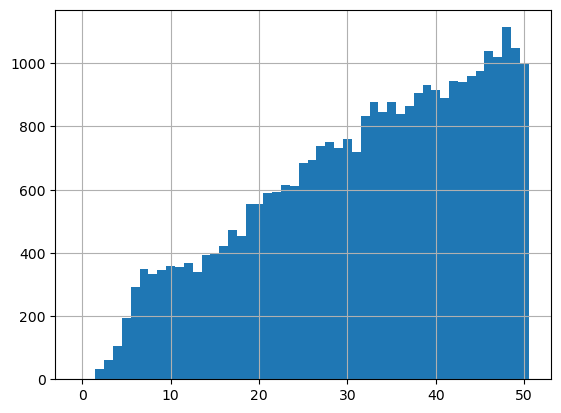

In [21]:
selected_loops_df['bin_distance'].hist(bins=51, range=(-0.5,50.5))

<Axes: >

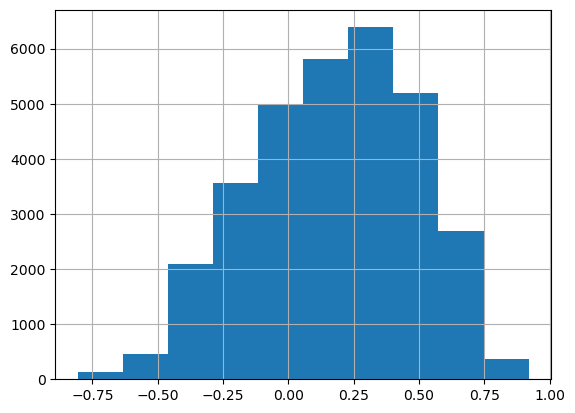

In [22]:
selected_loops_df['PCC_5hmCG_RNA'].hist()

<Axes: >

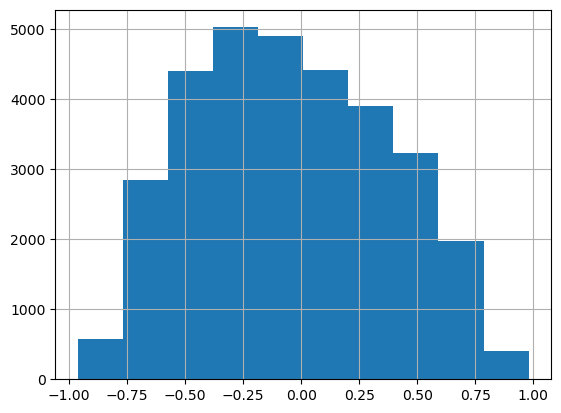

In [23]:
selected_loops_df['PCC_3C_RNA'].hist()

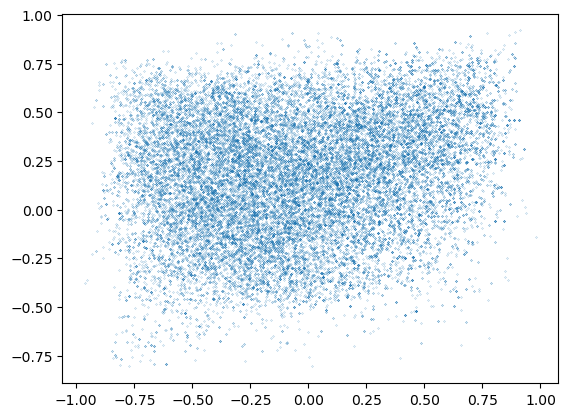

In [24]:
plt.scatter(selected_loops_df['PCC_3C_RNA'], selected_loops_df['PCC_5hmCG_RNA'], marker='.', edgecolors=None, s=0.1)

In [25]:
selected_loops_df[(selected_loops_df['gene_id']=='ENSMUSG00000050830.17') & (selected_loops_df['bin_intergenic_in_chromosome'].apply(lambda x : 1080<= x <=1086))]

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
8191,153669,153704,chr11,1080,ENSMUSG00000050830.17,0.319199,35,0.521497
17345,153670,153715,chr11,1081,ENSMUSG00000050830.17,0.513708,45,0.464441
19277,153671,153709,chr11,1082,ENSMUSG00000050830.17,0.657940,38,0.541791
20937,153671,153700,chr11,1082,ENSMUSG00000050830.17,0.657940,29,0.541791
27041,153672,153700,chr11,1083,ENSMUSG00000050830.17,0.725051,28,0.449660
27042,153671,153711,chr11,1082,ENSMUSG00000050830.17,0.657940,40,0.541791
31943,153670,153703,chr11,1081,ENSMUSG00000050830.17,0.513708,33,0.464441
37910,153674,153712,chr11,1085,ENSMUSG00000050830.17,0.634294,38,0.375851
39539,153672,153701,chr11,1083,ENSMUSG00000050830.17,0.725051,29,0.449660
41117,153672,153711,chr11,1083,ENSMUSG00000050830.17,0.725051,39,0.449660


In [26]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=40)]
x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::3]
y=y[::3]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

2025-01-06 20:26:27.973333	 Started kde
2025-01-06 20:26:29.027951	 kde done


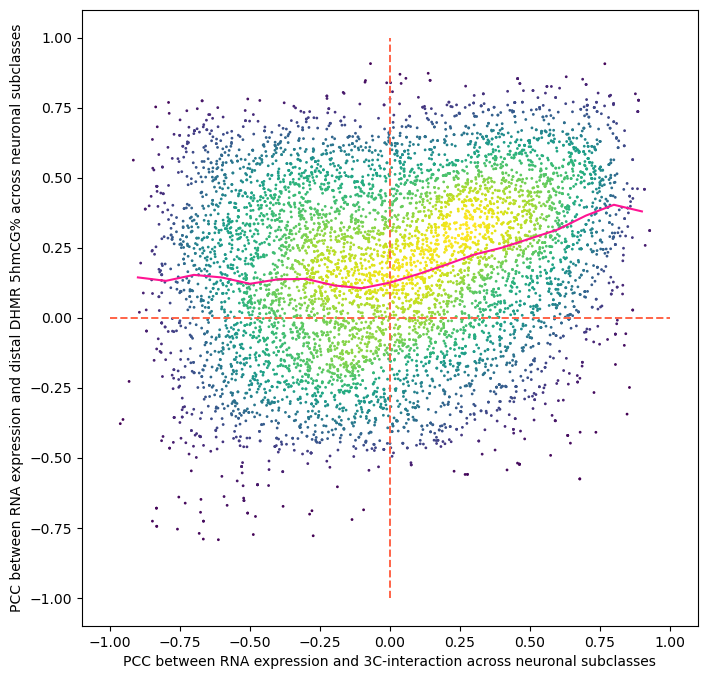

In [27]:
plt.figure(figsize=(8,8))
plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None, cmap='viridis')

plt.xlabel('PCC between RNA expression and 3C-interaction across neuronal subclasses')
plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG% across neuronal subclasses')
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.1;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[1:-1]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-average_range<=p<=x+average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.show()

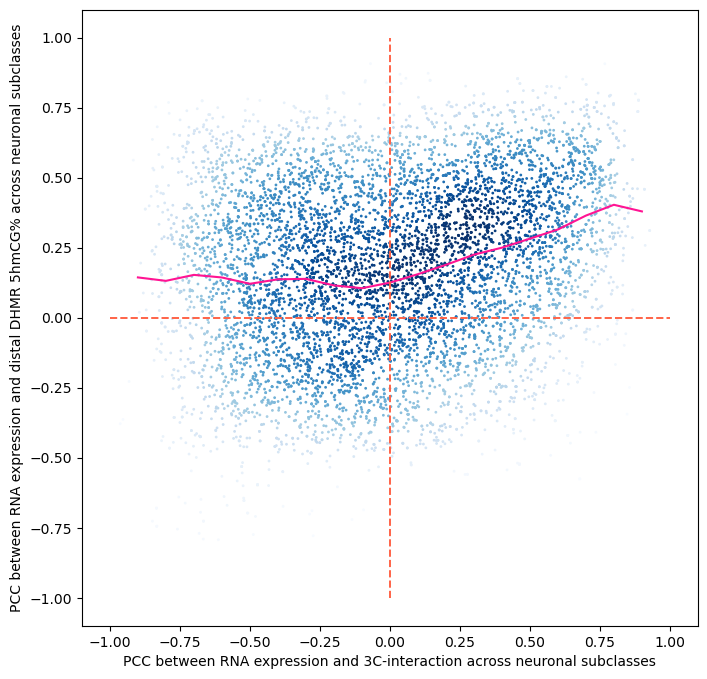

In [28]:
plt.figure(figsize=(8,8))
plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None, cmap='Blues')

plt.xlabel('PCC between RNA expression and 3C-interaction across neuronal subclasses')
plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG% across neuronal subclasses')
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.1;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[1:-1]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-average_range<=p<=x+average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.show()

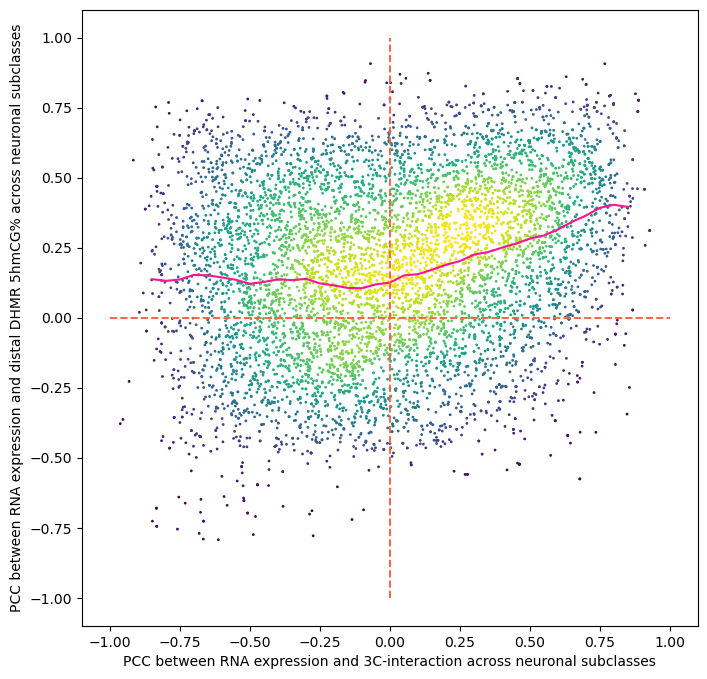

In [114]:
plt.figure(figsize=(8,8))
plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None)

plt.xlabel('PCC between RNA expression and 3C-interaction across neuronal subclasses')
plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG% across neuronal subclasses')
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.show()

In [138]:
selected_loops_df.to_csv('selected_loops.csv', index=False)

In [139]:
ls

5hmCG_frac_chrom30k_step10k_by_subclass.h5ad
get_Distal30kbRegion_gene_pair_PCC.ipynb
get_h5ad_from_MCDS.py
get_sliding_30kb_bin_5hmCG_mcds.ipynb
get_subclass_30kb_bin_mcds.sh
logs/
mcds_data_sliding_30kb_bins_10kb_step/
plots_PCC_3C_RNA_PCC_5hmCG_RNA/
selected_loops.csv
sliding_30kb_bins_10kb_step.bed


lower_bin_limit: 2; upper_bin_limit: 10.
2025-01-02 23:06:46.071568	 Started kde
2025-01-02 23:06:46.184946	 kde done


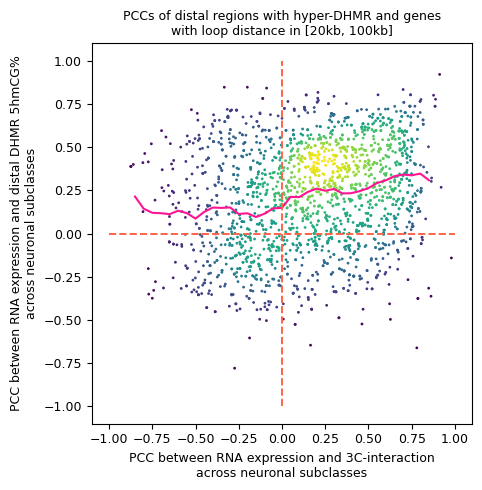

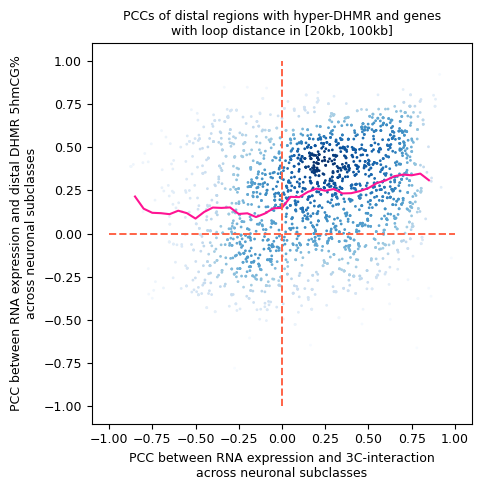

lower_bin_limit: 2; upper_bin_limit: 20.
2025-01-02 23:06:48.005901	 Started kde
2025-01-02 23:06:48.786167	 kde done


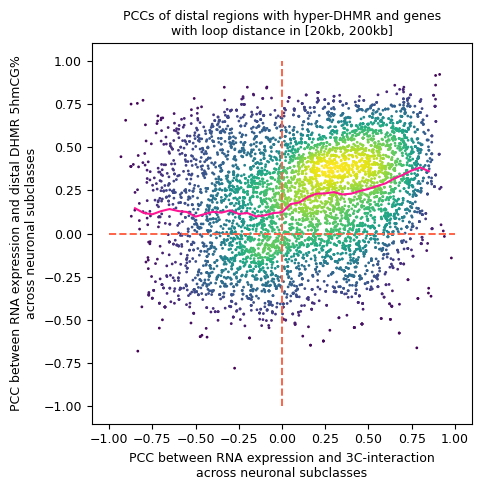

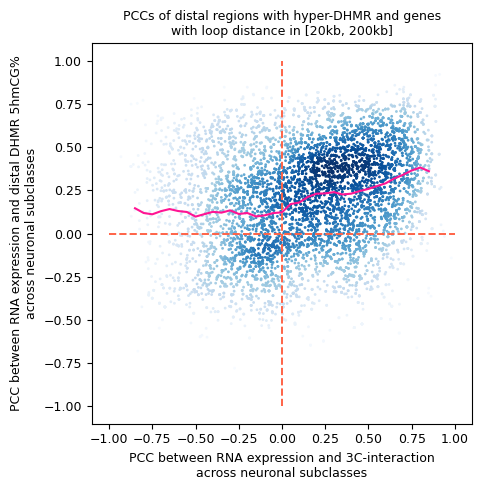

lower_bin_limit: 2; upper_bin_limit: 30.
2025-01-02 23:06:51.454209	 Started kde
2025-01-02 23:06:54.644028	 kde done


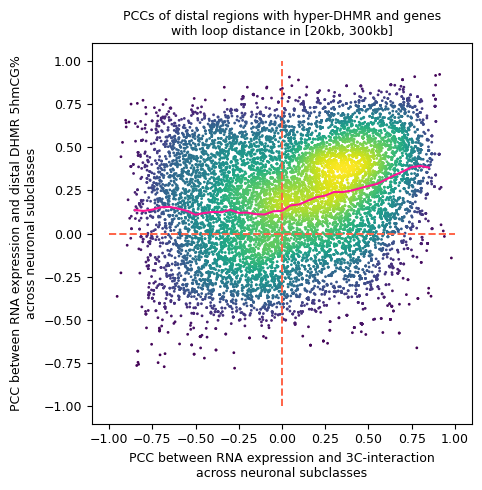

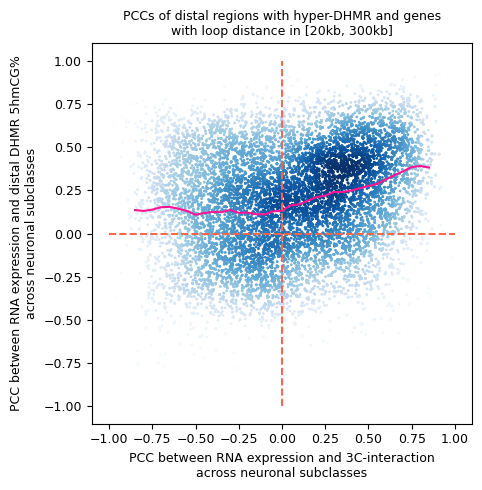

lower_bin_limit: 2; upper_bin_limit: 40.
2025-01-02 23:06:58.565837	 Started kde
2025-01-02 23:07:07.240088	 kde done


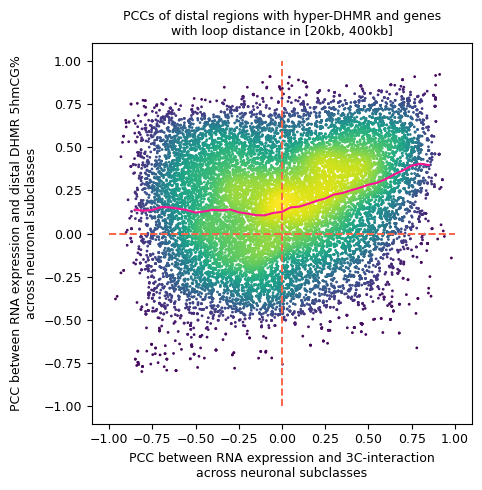

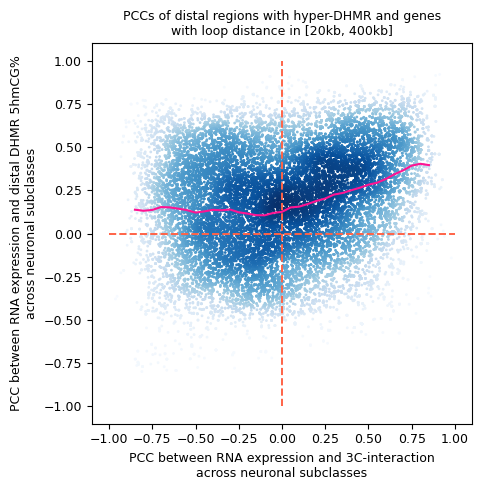

lower_bin_limit: 2; upper_bin_limit: 50.
2025-01-02 23:07:12.706594	 Started kde
2025-01-02 23:07:31.044346	 kde done


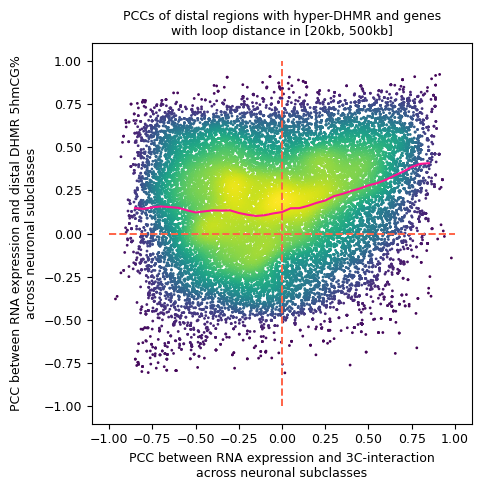

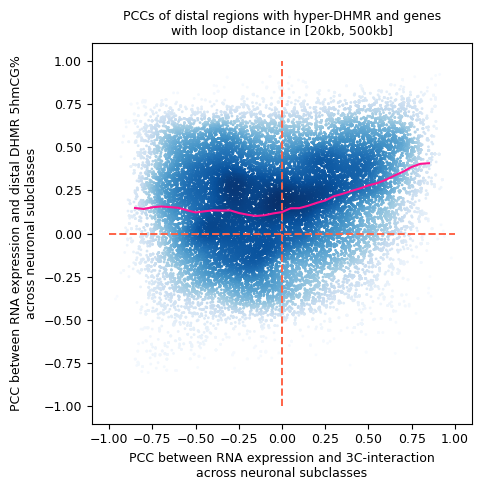

lower_bin_limit: 5; upper_bin_limit: 10.
2025-01-02 23:07:38.243557	 Started kde
2025-01-02 23:07:38.342656	 kde done


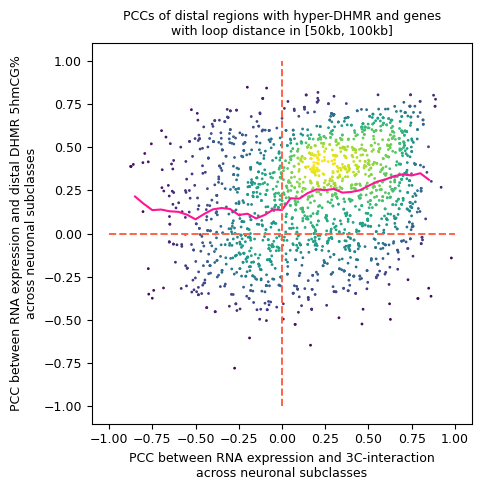

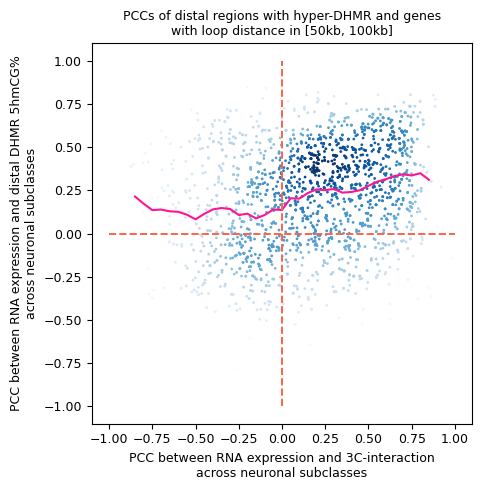

lower_bin_limit: 5; upper_bin_limit: 20.
2025-01-02 23:07:40.125180	 Started kde
2025-01-02 23:07:40.860133	 kde done


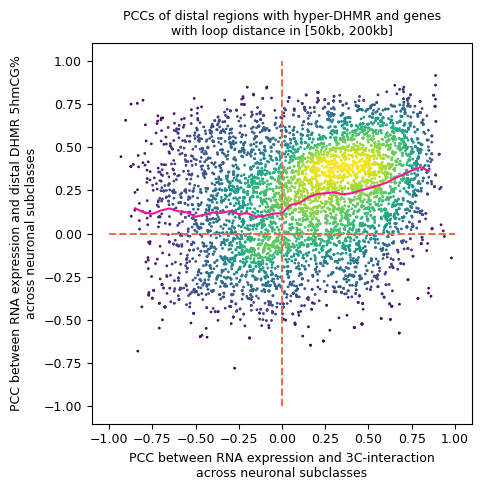

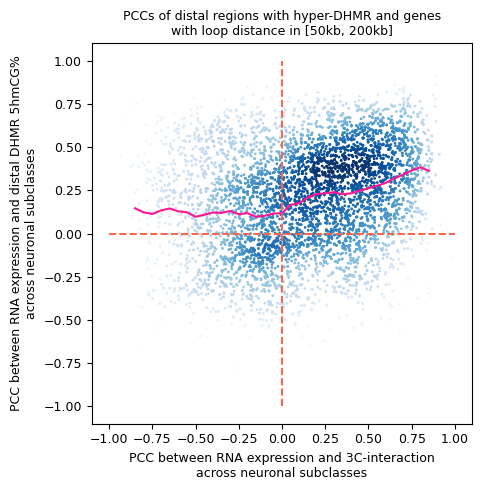

lower_bin_limit: 5; upper_bin_limit: 30.
2025-01-02 23:07:43.498796	 Started kde
2025-01-02 23:07:46.598438	 kde done


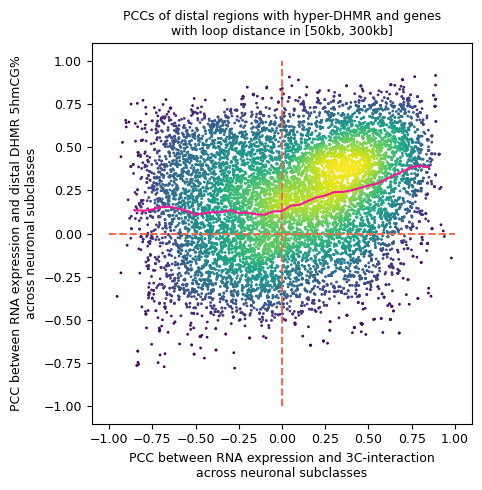

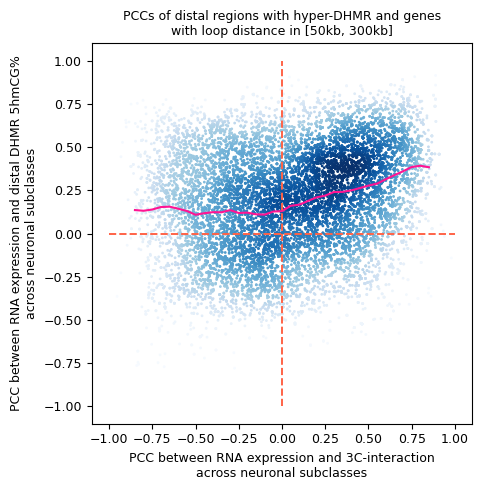

lower_bin_limit: 5; upper_bin_limit: 40.
2025-01-02 23:07:50.519020	 Started kde
2025-01-02 23:07:59.030823	 kde done


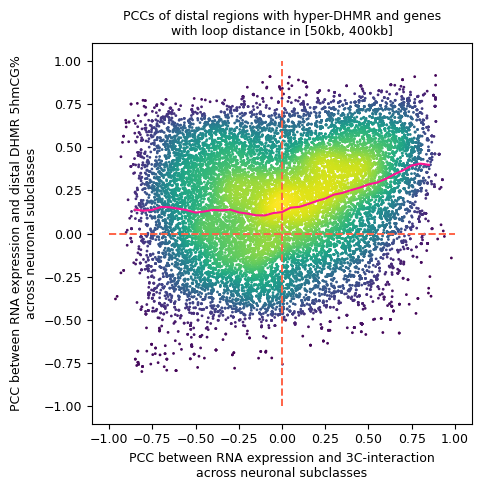

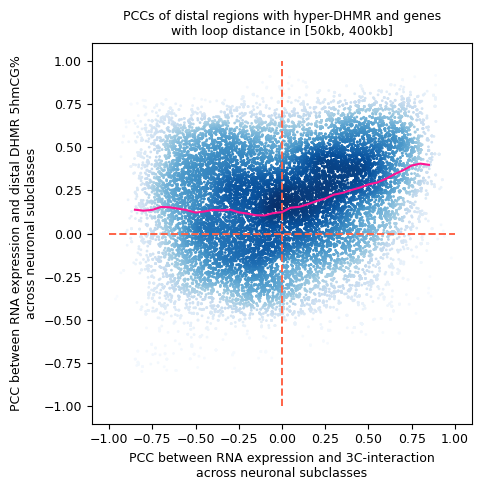

lower_bin_limit: 5; upper_bin_limit: 50.
2025-01-02 23:08:04.532203	 Started kde
2025-01-02 23:08:22.650801	 kde done


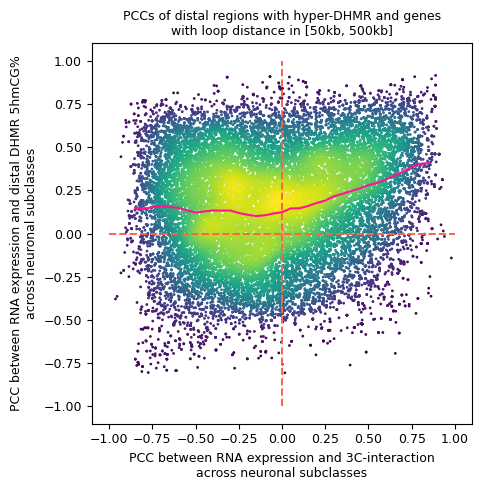

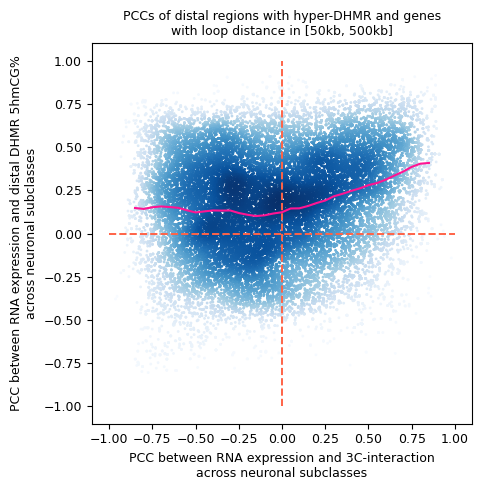

lower_bin_limit: 10; upper_bin_limit: 10.
2025-01-02 23:08:29.883933	 Started kde
2025-01-02 23:08:29.888413	 kde done


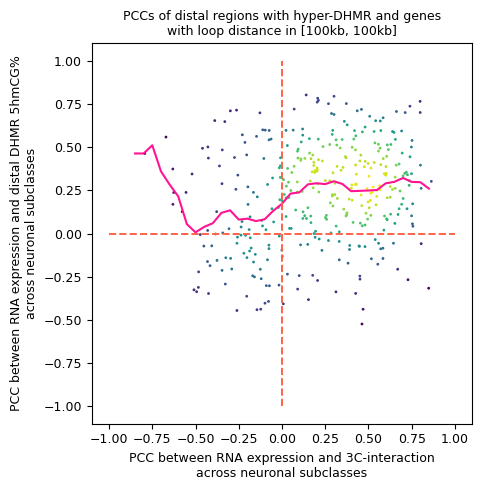

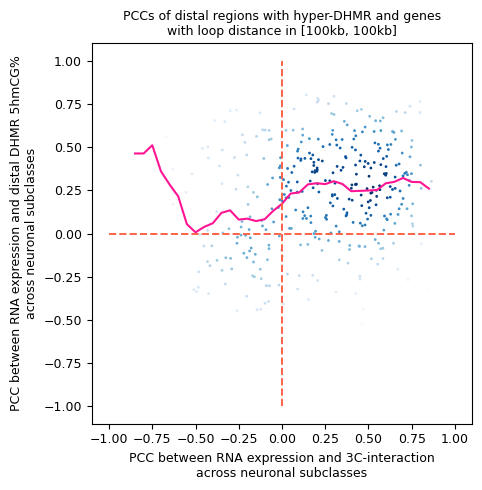

lower_bin_limit: 10; upper_bin_limit: 20.
2025-01-02 23:08:31.383944	 Started kde
2025-01-02 23:08:31.818025	 kde done


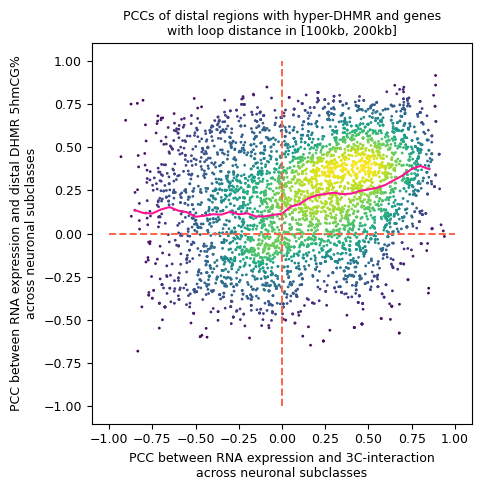

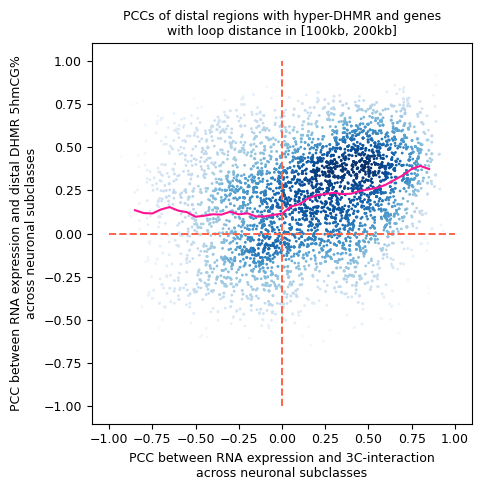

lower_bin_limit: 10; upper_bin_limit: 30.
2025-01-02 23:08:34.164373	 Started kde
2025-01-02 23:08:36.587301	 kde done


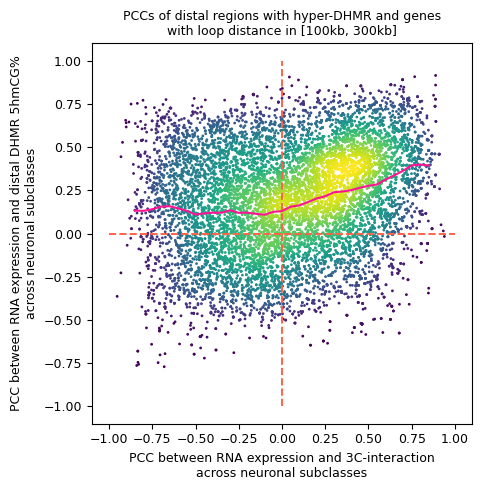

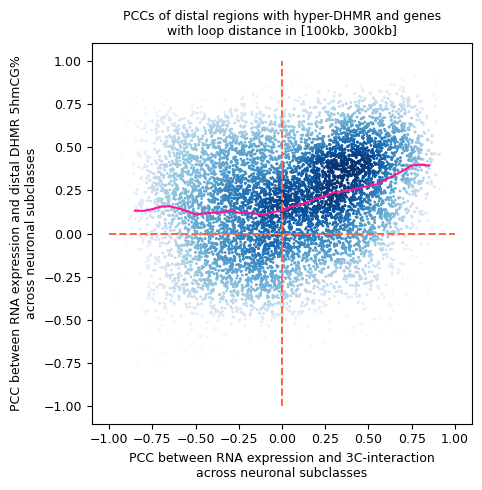

lower_bin_limit: 10; upper_bin_limit: 40.
2025-01-02 23:08:40.767146	 Started kde
2025-01-02 23:08:48.132790	 kde done


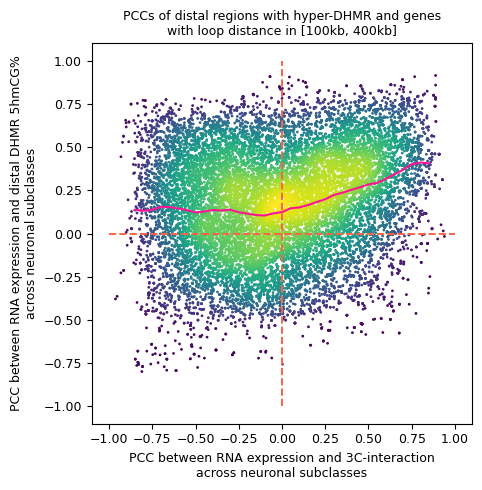

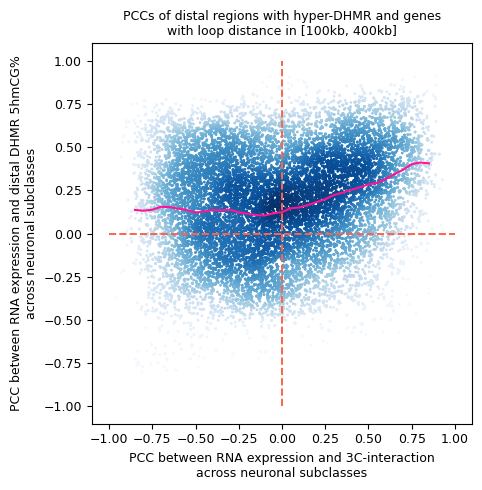

lower_bin_limit: 10; upper_bin_limit: 50.
2025-01-02 23:08:53.344600	 Started kde
2025-01-02 23:09:09.757457	 kde done


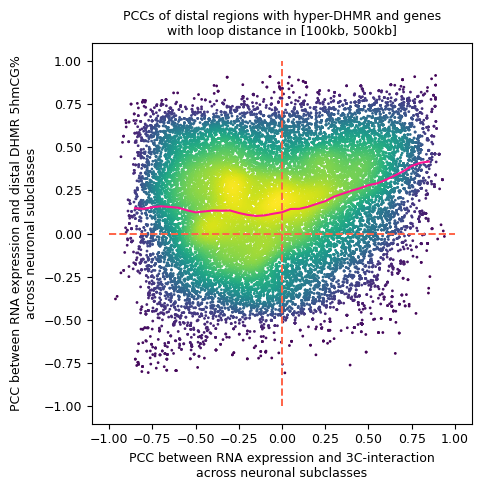

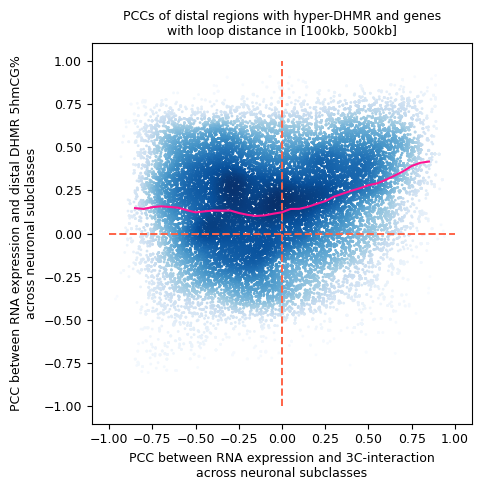

In [ ]:
for lower_bin_limit in [2,5,10]:
    for upper_bin_limit in [10,20,30,40,50]:
        # if lower_bin_limit>=upper_bin_limit:
        #     continue
        print(f'lower_bin_limit: {lower_bin_limit}; upper_bin_limit: {upper_bin_limit}.')
        PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : lower_bin_limit<=x<=upper_bin_limit)]
        x=PCC_df['PCC_3C_RNA'].to_numpy()
        y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
        x=x[::1]
        y=y[::1]
        x_and_y=np.vstack([x,y])
        print(f'{datetime.now()}\t Started kde')
        kde=gaussian_kde(x_and_y)
        z=kde(x_and_y)
        idx=z.argsort()
        x,y,z=x[idx],y[idx],z[idx]
        print(f'{datetime.now()}\t kde done')
        for cmap_ in ['viridis', 'Blues']:
            plt.figure(figsize=(5,5))
            plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None, cmap=cmap_)
            
            plt.xlabel('PCC between RNA expression and 3C-interaction\nacross neuronal subclasses', fontdict={'size':9})
            plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG%\nacross neuronal subclasses', fontdict={'size':9})
            plt.gca().set_aspect('equal')
            # also drawing the average 5hmCG-RNA_correlation line
            average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
            PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
            plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')
            
            plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
            plt.xticks(size=9)
            plt.yticks(size=9)
            plt.title(f'PCCs of distal regions with hyper-DHMR and genes\nwith loop distance in [{lower_bin_limit*10}kb, {upper_bin_limit*10}kb]', size=9)
            plt.tight_layout()
            plt.savefig(f'{outdir}/PCCs_scatterplot_distance_{lower_bin_limit}_{upper_bin_limit}-{cmap_}.pdf')
            plt.savefig(f'{outdir}/PCCs_scatterplot_distance_{lower_bin_limit}_{upper_bin_limit}-{cmap_}.png', dpi=600)
            plt.show()


(array([ 391.,  692.,  864., 1331., 1217., 1114., 1356., 1571., 1039.,
        1273.]),
 array([0.00403394, 0.1159872 , 0.22794047, 0.33989374, 0.451847  ,
        0.56380027, 0.67575354, 0.7877068 , 0.89966007, 1.01161334,
        1.12356661]),
 <BarContainer object of 10 artists>)

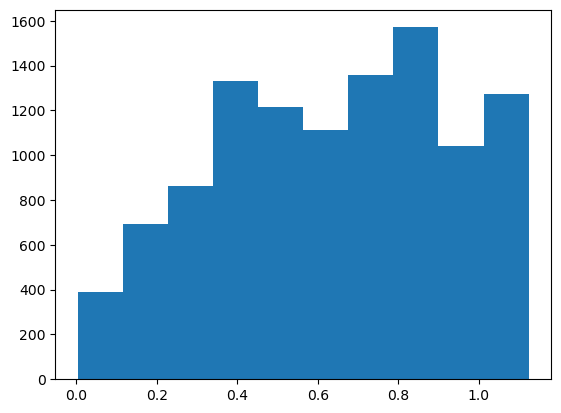

In [118]:
plt.hist(z)

lower_bin_limit: 40; upper_bin_limit: 50.
2025-01-03 16:35:01.199164	 Started kde
2025-01-03 16:35:03.375509	 kde done


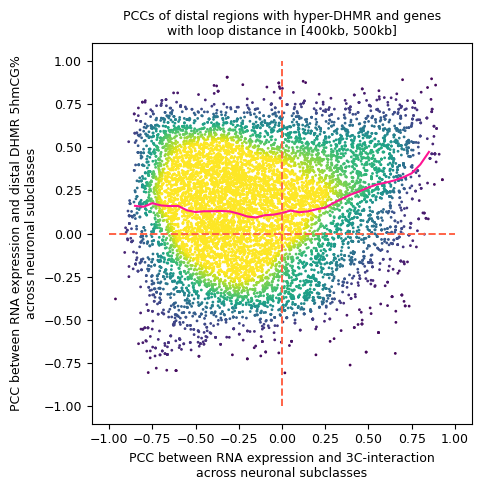

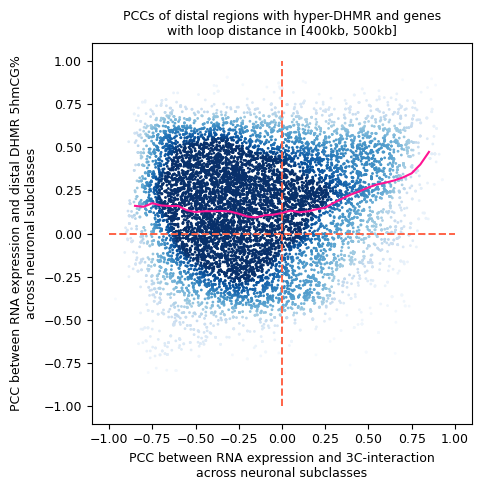

In [120]:
for lower_bin_limit in [40]:
    for upper_bin_limit in [50]:
        # if lower_bin_limit>=upper_bin_limit:
        #     continue
        print(f'lower_bin_limit: {lower_bin_limit}; upper_bin_limit: {upper_bin_limit}.')
        PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : lower_bin_limit<=x<=upper_bin_limit)]
        x=PCC_df['PCC_3C_RNA'].to_numpy()
        y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
        x=x[::1]
        y=y[::1]
        x_and_y=np.vstack([x,y])
        print(f'{datetime.now()}\t Started kde')
        kde=gaussian_kde(x_and_y)
        z=kde(x_and_y)
        idx=z.argsort()
        x,y,z=x[idx],y[idx],z[idx]
        print(f'{datetime.now()}\t kde done')
        for cmap_ in ['viridis', 'Blues']:
            plt.figure(figsize=(5,5))
            plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None, cmap=cmap_,vmin=0,vmax=0.7)
            
            plt.xlabel('PCC between RNA expression and 3C-interaction\nacross neuronal subclasses', fontdict={'size':9})
            plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG%\nacross neuronal subclasses', fontdict={'size':9})
            plt.gca().set_aspect('equal')
            # also drawing the average 5hmCG-RNA_correlation line
            average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
            PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
            plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')
            
            plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
            plt.xticks(size=9)
            plt.yticks(size=9)
            plt.title(f'PCCs of distal regions with hyper-DHMR and genes\nwith loop distance in [{lower_bin_limit*10}kb, {upper_bin_limit*10}kb]', size=9)
            plt.tight_layout()
            # plt.savefig(f'./plots_PCC_3C_RNA_PCC_5hmCG_RNA/PCCs_scatterplot_distance_{lower_bin_limit}_{upper_bin_limit}-{cmap_}.pdf')
            # plt.savefig(f'./plots_PCC_3C_RNA_PCC_5hmCG_RNA/PCCs_scatterplot_distance_{lower_bin_limit}_{upper_bin_limit}-{cmap_}.png', dpi=600)
            plt.show()


In [132]:
from collections import Counter
Counter(PCC_df[['bin_intergenic','bin_gene','chromosome']].value_counts())

Counter({1: 29409, 2: 290})

lower_bin_limit: 2; upper_bin_limit: 10.
pair number for every gene: 2.698309492847854
gene number for every loop: 1.0067928190198931


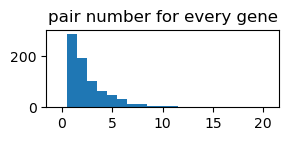

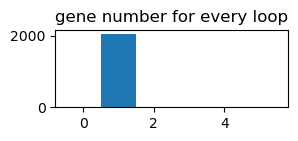

lower_bin_limit: 2; upper_bin_limit: 20.
pair number for every gene: 5.399493243243243
gene number for every loop: 1.0086778163458505


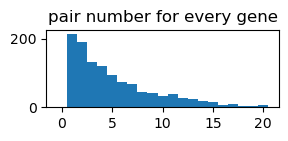

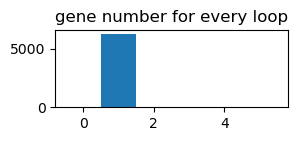

lower_bin_limit: 2; upper_bin_limit: 30.
pair number for every gene: 9.55918663761801
gene number for every loop: 1.009509931743232


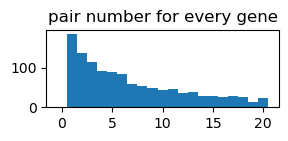

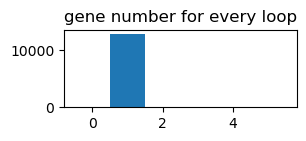

lower_bin_limit: 2; upper_bin_limit: 40.
pair number for every gene: 14.49600532623169
gene number for every loop: 1.010113662723266


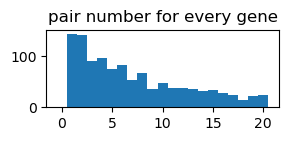

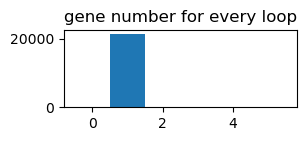

lower_bin_limit: 2; upper_bin_limit: 50.
pair number for every gene: 20.04045512010114
gene number for every loop: 1.009585071489985


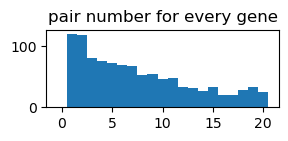

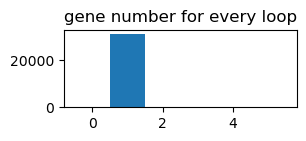

lower_bin_limit: 5; upper_bin_limit: 10.
pair number for every gene: 2.564207650273224
gene number for every loop: 1.0075147611379496


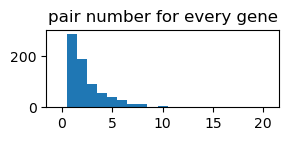

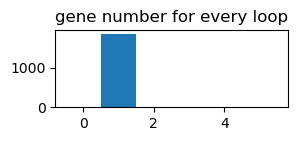

lower_bin_limit: 5; upper_bin_limit: 20.
pair number for every gene: 5.294871794871795
gene number for every loop: 1.008957654723127


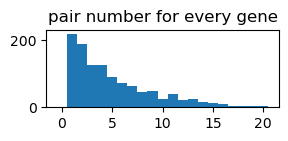

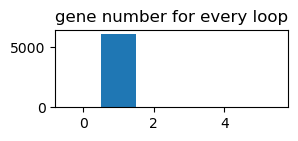

lower_bin_limit: 5; upper_bin_limit: 30.
pair number for every gene: 9.484272128749085
gene number for every loop: 1.0096565688030528


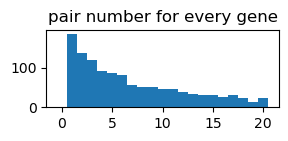

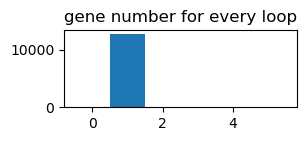

lower_bin_limit: 5; upper_bin_limit: 40.
pair number for every gene: 14.441097724230254
gene number for every loop: 1.0102074261366296


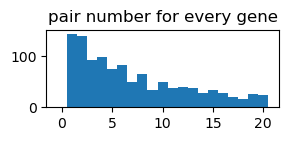

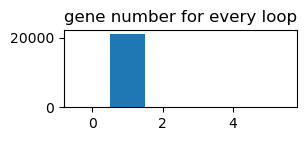

lower_bin_limit: 5; upper_bin_limit: 50.
pair number for every gene: 19.991116751269036
gene number for every loop: 1.0096458900817176


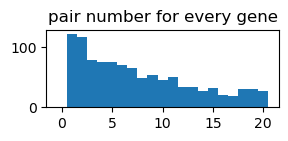

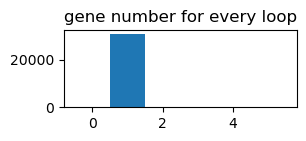

lower_bin_limit: 10; upper_bin_limit: 10.
pair number for every gene: 1.2811387900355873
gene number for every loop: 1.0084033613445378


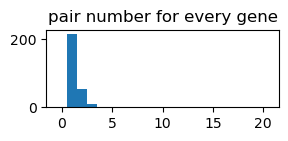

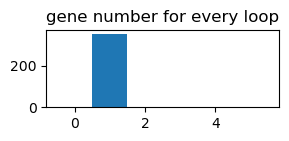

lower_bin_limit: 10; upper_bin_limit: 20.
pair number for every gene: 4.5285575992255565
gene number for every loop: 1.009495036685369


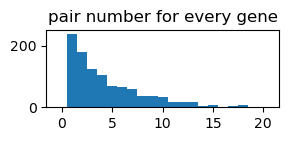

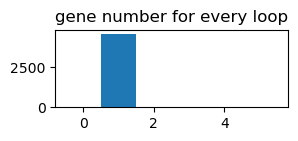

lower_bin_limit: 10; upper_bin_limit: 30.
pair number for every gene: 8.867544539116963
gene number for every loop: 1.0099691221879135


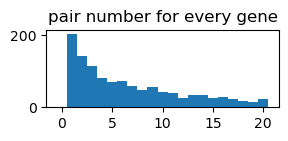

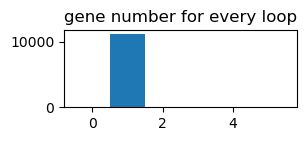

lower_bin_limit: 10; upper_bin_limit: 40.
pair number for every gene: 13.890581717451523
gene number for every loop: 1.0104276862626569


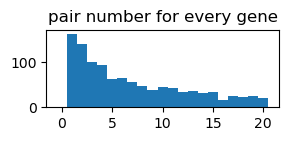

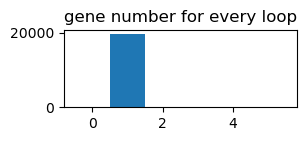

lower_bin_limit: 10; upper_bin_limit: 50.
pair number for every gene: 19.46073977936405
gene number for every loop: 1.009764638540018


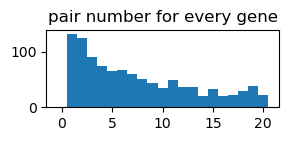

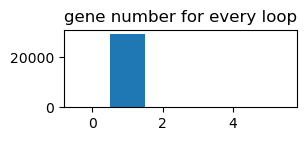

In [136]:
for lower_bin_limit in [2,5,10]:
    for upper_bin_limit in [10,20,30,40,50]:
        print(f'lower_bin_limit: {lower_bin_limit}; upper_bin_limit: {upper_bin_limit}.')
        PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : lower_bin_limit<=x<=upper_bin_limit)]
        print(f'pair number for every gene: {PCC_df['gene_id'].value_counts().mean()}')
        print(f'gene number for every loop: {PCC_df[['bin_intergenic','bin_gene','chromosome']].value_counts().mean()}')
        plt.figure(figsize=(3,1))
        plt.hist(PCC_df['gene_id'].value_counts(),range=(-0.5,20.5), bins=21)
        plt.title('pair number for every gene'); plt.show()
        plt.figure(figsize=(3,1))
        plt.hist(PCC_df[['bin_intergenic','bin_gene','chromosome']].value_counts(), range=(-0.5,5.5),bins=6)
        plt.title('gene number for every loop'); plt.show()


bin_intergenic  bin_gene  chromosome
103653          103662    chr7          2
103652          103662    chr7          2
140227          140219    chr10         2
                140220    chr10         2
140228          140220    chr10         2
                                       ..
79587           79595     chr5          1
79588           79595     chr5          1
                79596     chr5          1
79590           79596     chr5          1
78720           78711     chr5          1
Name: count, Length: 2061, dtype: int64

In [78]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : True)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

(17381, 5)


In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = f"{indir}/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size']=5

(8100, 5)
2025-01-06 21:08:24.240260	 Started kde
2025-01-06 21:08:25.468322	 kde done


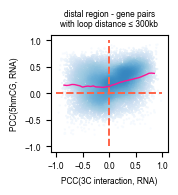

In [ ]:
# only showing distal region with hyper DHMR - gene pairs, with the loop distance in the range [20kb, 300kb]
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=30)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::1]
y=y[::1]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

cmap_ = 'Blues'
plt.figure(figsize=(45/25.4,50/25.4))
plt.scatter(x, y ,c=z, marker='.', s=1,edgecolors=None, cmap=cmap_,vmin=0,vmax=1.5)

plt.xlabel('PCC(3C interaction, RNA)', fontdict={'size':6})
plt.ylabel('PCC(5hmCG, RNA)', fontdict={'size':6})
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink', linewidth=1)

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.xticks(size=6)
plt.yticks(size=6)
plt.title(f'distal region - gene pairs\nwith loop distance ≤ 300kb', size=6)
plt.tight_layout()
plt.savefig(f'{outdir}/PCCscatterplot_within300kb.pdf')
plt.savefig(f'{outdir}/PCCscatterplot_within300kb.png', dpi=600)
plt.show()

(11430, 5)
2025-01-06 21:09:55.207130	 Started kde
2025-01-06 21:09:57.664807	 kde done


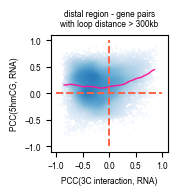

In [ ]:
# only showing distal region with hyper DHMR - gene pairs, with the loop distance in the range (300kb, 500kb]
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 30<x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::1]
y=y[::1]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

cmap_ = 'Blues'
plt.figure(figsize=(45/25.4,50/25.4))
plt.scatter(x, y ,c=z, marker='.', s=1,edgecolors=None, cmap=cmap_,vmin=0,vmax=1.5)

plt.xlabel('PCC(3C interaction, RNA)', fontdict={'size':6})
plt.ylabel('PCC(5hmCG, RNA)', fontdict={'size':6})
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink', linewidth=1)

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.xticks(size=6)
plt.yticks(size=6)
plt.title(f'distal region - gene pairs\nwith loop distance > 300kb', size=6)
plt.tight_layout()
plt.savefig(f'{outdir}/PCCscatterplot_over300kb.pdf')
plt.savefig(f'{outdir}/PCCscatterplot_over300kb.png', dpi=600)
plt.show()

(17381, 5)
2025-01-06 21:14:54.756315	 Started kde
2025-01-06 21:15:00.303484	 kde done


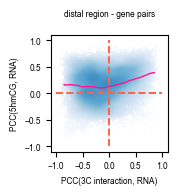

In [ ]:
# only showing distal region with hyper DHMR - gene pairs, with the loop distance in the range [20kb, 500kb]
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::1]
y=y[::1]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

cmap_ = 'Blues'
plt.figure(figsize=(45/25.4,50/25.4))
plt.scatter(x, y ,c=z, marker='.', s=1,edgecolors=None, cmap=cmap_,vmin=0,vmax=1.5)

plt.xlabel('PCC(3C interaction, RNA)', fontdict={'size':6})
plt.ylabel('PCC(5hmCG, RNA)', fontdict={'size':6})
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink', linewidth=1)

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.xticks(size=6)
plt.yticks(size=6)
plt.title(f'distal region - gene pairs\n', size=6)
plt.tight_layout()
plt.savefig(f'{outdir}/PCCscatterplot_all.pdf')
plt.savefig(f'{outdir}/PCCscatterplot_all.png', dpi=600)
plt.show()

In [ ]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 30<x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
PCC_df.to_csv(f'{outdir}/PCC_df_lt30_se50.csv')

In [ ]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=30)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
PCC_df.to_csv(f'{outdir}/PCC_df_le2_se30.csv')

In [ ]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
PCC_df.to_csv(f'{outdir}/PCC_df_le2_se50.csv')